In [9]:

import numpy as np
from optimum.intel.openvino import OVModelForCausalLM
from transformers import AutoTokenizer

import nncf

In [ ]:
# MODEL_ID = "/home/dlyakhov/Projects/optimum-intel/falcon_fp32"
MODEL_ID = "tiiuae/falcon-mamba-7b"


tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = OVModelForCausalLM.from_pretrained(MODEL_ID, export=True, load_in_8bit=False, compile=False)
# model = OVModelForCausalLM.from_pretrained(MODEL_ID)

No OpenVINO files were found for tiiuae/falcon-mamba-7b, setting `export=True` to convert the model to the OpenVINO IR. Don't forget to save the resulting model with `.save_pretrained()`


KeyboardInterrupt: 

In [3]:
ov_model_fp = model.model

In [4]:
from optimum.gptq.data import get_dataset
from optimum.gptq.data import prepare_dataset

dataset = "wikitext2"
seqlen = 50
nsamples = 2
calibration_dataset = get_dataset(dataset, tokenizer, seqlen=seqlen, nsamples=nsamples)
calibration_dataset = prepare_dataset(calibration_dataset)
quantization_dataset = nncf.Dataset(calibration_dataset, lambda x: model.prepare_inputs(**x))

In [ ]:
from profiler import NNCFProfiler

regex = r'.*mixer.*_proj/ov_ext::linear/MatMul'
# profiler = NNCFProfiler(pattern = r'.*mixer\.conv_sequence_transform.act/aten::silu/Swish_1', dataset=quantization_dataset, num_samples=2)
profiler = NNCFProfiler(pattern = regex, dataset=quantization_dataset, num_samples=2)


/home/dlyakhov/Projects/nncf/env/lib/python3.10/site-packages/openvino/runtime/__init__.py:10: DeprecationWarning: The `openvino.runtime` module is deprecated and will be removed in the 2026.0 release. Please replace `openvino.runtime` with `openvino`.
  warnings.warn(


In [ ]:
data_fp = profiler.collect_activations(ov_model_fp)

In [7]:
data_fp.keys()

dict_keys(['__module.backbone.layers.0.mixer.in_proj/ov_ext::linear/MatMul', '__module.backbone.layers.0.mixer.x_proj/ov_ext::linear/MatMul', '__module.backbone.layers.0.mixer.dt_proj/ov_ext::linear/MatMul', '__module.backbone.layers.0.mixer.out_proj/ov_ext::linear/MatMul', '__module.backbone.layers.1.mixer.in_proj/ov_ext::linear/MatMul', '__module.backbone.layers.1.mixer.x_proj/ov_ext::linear/MatMul', '__module.backbone.layers.1.mixer.dt_proj/ov_ext::linear/MatMul', '__module.backbone.layers.1.mixer.out_proj/ov_ext::linear/MatMul', '__module.backbone.layers.2.mixer.in_proj/ov_ext::linear/MatMul', '__module.backbone.layers.2.mixer.x_proj/ov_ext::linear/MatMul', '__module.backbone.layers.2.mixer.dt_proj/ov_ext::linear/MatMul', '__module.backbone.layers.2.mixer.out_proj/ov_ext::linear/MatMul', '__module.backbone.layers.3.mixer.in_proj/ov_ext::linear/MatMul', '__module.backbone.layers.3.mixer.x_proj/ov_ext::linear/MatMul', '__module.backbone.layers.3.mixer.dt_proj/ov_ext::linear/MatMul', 

In [8]:
stats_fp = profiler.calculate_stats(data_fp, statistics=["min", "max", "mean"])
stats_fp.head()

,name,type,min,max,mean
0,__module.backbone.layers.0.mixer.in_proj/ov_ex...,in,-9.578212,5.136457,-0.000884
1,__module.backbone.layers.0.mixer.in_proj/ov_ex...,out,-12.938580,12.325294,-0.075227
2,__module.backbone.layers.0.mixer.x_proj/ov_ext...,in,-0.278465,3.530993,0.004914
3,__module.backbone.layers.0.mixer.x_proj/ov_ext...,out,-2.849676,5.468871,0.013442
4,__module.backbone.layers.0.mixer.dt_proj/ov_ex...,in,-4.855822,15.203080,0.056611


In [9]:
stats_fp

,name,type,min,max,mean
0,__module.backbone.layers.0.mixer.in_proj/ov_ex...,in,-9.578212,5.136457,-0.000884
1,__module.backbone.layers.0.mixer.in_proj/ov_ex...,out,-12.938580,12.325294,-0.075227
2,__module.backbone.layers.0.mixer.x_proj/ov_ext...,in,-0.278465,3.530993,0.004914
3,__module.backbone.layers.0.mixer.x_proj/ov_ext...,out,-2.849676,5.468871,0.013442
4,__module.backbone.layers.0.mixer.dt_proj/ov_ex...,in,-4.855822,15.203080,0.056611
...,...,...,...,...,...
507,__module.backbone.layers.63.mixer.x_proj/ov_ex...,out,-6.435536,6.772291,0.015536
508,__module.backbone.layers.63.mixer.dt_proj/ov_e...,in,-5.173365,7.268032,0.076712
509,__module.backbone.layers.63.mixer.dt_proj/ov_e...,out,-6.825014,10.373165,0.606490
510,__module.backbone.layers.63.mixer.out_proj/ov_...,in,-26.446564,19.116121,-0.008682


In [ ]:
# It's possible to register your own statistics

@NNCFProfiler.statistic("percentile_95")
def _stat_percentile_95(vals: np.ndarray) -> float:
    """Calculate the 95th percentile of activations."""
    return float(np.percentile(vals, 95))


stats_fp = profiler.calculate_stats(data_fp, statistics=["min", "max", "mean", "percentile_95"])
stats_fp.head()

,name,type,min,max,mean,percentile_95
0,__module.model.layers.0.self_attn.k_proj/ov_ex...,in,-3.702809,4.830170,0.000816,0.011473
1,__module.model.layers.0.self_attn.k_proj/ov_ex...,out,-13.699491,5.540934,-0.086840,1.881651
2,__module.model.layers.1.self_attn.k_proj/ov_ex...,in,-8.973475,2.948636,-0.004756,0.050166
3,__module.model.layers.1.self_attn.k_proj/ov_ex...,out,-6.133480,8.753073,0.074276,3.285733
4,__module.model.layers.2.self_attn.k_proj/ov_ex...,in,-7.766637,3.266993,-0.004558,0.101055


In [ ]:
from nncf import CompressWeightsMode
from nncf import compress_weights

ov_model_int8 = compress_weights(ov_model_fp, mode=CompressWeightsMode.INT8_SYM, ratio=1.0)

In [10]:
COMPRESSED_MODEL_ID = "/home/dlyakhov/Projects/optimum-intel/test_1_12_25"

model_int8 = OVModelForCausalLM.from_pretrained(COMPRESSED_MODEL_ID)
ov_model_int8 = model_int8.model

`dynamic_shapes` was set to True, but this value will be ignored as only dynamic shapes are supported.


In [11]:
data_int8 = profiler.collect_activations(ov_model_int8)

/home/dlyakhov/Projects/nncf/env/lib/python3.10/site-packages/rich/live.py:256: UserWarning: install "ipywidgets" 
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

In [12]:
comp_res = profiler.compare_activations(data_fp, data_int8, metrics=["mean_diff", "std_diff"], statistics = ["min", "max", "mean"])
comp_res.head()

,name,type,min_data1,max_data1,mean_data1,min_data2,max_data2,mean_data2,mean_diff,std_diff
0,__module.backbone.layers.0.mixer.in_proj/ov_ex...,in,-9.578212,5.136457,-0.000884,-9.553921,5.119579,-0.000912,0.000028,0.011058
1,__module.backbone.layers.0.mixer.in_proj/ov_ex...,out,-12.938580,12.325294,-0.075227,-13.064135,12.313551,-0.075330,0.000103,0.042362
2,__module.backbone.layers.0.mixer.x_proj/ov_ext...,in,-0.278465,3.530993,0.004914,-0.930711,6.348646,0.008095,-0.00318,0.028932
3,__module.backbone.layers.0.mixer.x_proj/ov_ext...,out,-2.849676,5.468871,0.013442,-2.828919,5.346360,0.012776,0.000665,0.01447
4,__module.backbone.layers.0.mixer.dt_proj/ov_ex...,in,-4.855822,15.203080,0.056611,-4.933422,15.190955,0.055476,0.001134,0.051297


In [13]:
# You can register your own function for comparing statistics

@NNCFProfiler.comparator("relative_diff")
def _relative_diff(a: np.ndarray, b: np.ndarray) -> float:
    """Calculate the mean relative difference between two activation arrays."""
    epsilon = 1e-8
    return float((np.abs(a - b) / (np.abs(a) + epsilon)).mean())

In [14]:
comp_res = profiler.compare_activations(data_fp, data_int8, metrics=["mean_diff", "std_diff", "relative_diff"], statistics = ["min", "max", "mean"])
comp_res.head()

,name,type,min_data1,max_data1,mean_data1,min_data2,max_data2,mean_data2,mean_diff,std_diff,relative_diff
0,__module.backbone.layers.0.mixer.in_proj/ov_ex...,in,-9.578212,5.136457,-0.000884,-9.553921,5.119579,-0.000912,0.000028,0.011058,0.208419
1,__module.backbone.layers.0.mixer.in_proj/ov_ex...,out,-12.938580,12.325294,-0.075227,-13.064135,12.313551,-0.075330,0.000103,0.042362,1.03686
2,__module.backbone.layers.0.mixer.x_proj/ov_ext...,in,-0.278465,3.530993,0.004914,-0.930711,6.348646,0.008095,-0.00318,0.028932,1.719728
3,__module.backbone.layers.0.mixer.x_proj/ov_ext...,out,-2.849676,5.468871,0.013442,-2.828919,5.346360,0.012776,0.000665,0.01447,0.797759
4,__module.backbone.layers.0.mixer.dt_proj/ov_ex...,in,-4.855822,15.203080,0.056611,-4.933422,15.190955,0.055476,0.001134,0.051297,0.886409


In [33]:
comp_res.sort_values(by="relative_diff", ascending=False).name

182    __module.backbone.layers.22.mixer.out_proj/ov_...
62     __module.backbone.layers.7.mixer.out_proj/ov_e...
190    __module.backbone.layers.23.mixer.out_proj/ov_...
254    __module.backbone.layers.31.mixer.out_proj/ov_...
246    __module.backbone.layers.30.mixer.out_proj/ov_...
                             ...                        
4      __module.backbone.layers.0.mixer.dt_proj/ov_ex...
3      __module.backbone.layers.0.mixer.x_proj/ov_ext...
5      __module.backbone.layers.0.mixer.dt_proj/ov_ex...
141    __module.backbone.layers.17.mixer.dt_proj/ov_e...
0      __module.backbone.layers.0.mixer.in_proj/ov_ex...
Name: name, Length: 512, dtype: object

In [ ]:
# It's also possible to register your own visualizer (see the implemenation in nncf/tools/profiler.py)

# @NNCFProfiler.visualizer("compare_detailed")
# def _compare_detailed_plot(
#     data1: ActivationData,
#     data2: ActivationData,
#     activation_type: Optional[str] = None,
#     bins: int = 100,
#     show_histograms: bool = True,
#     show_summary: bool = True,
#     display_figures: bool = False,
#     data1_label: str = 'data1',
#     data2_label: str = 'data2',
#     **kwargs
# ): 

In [15]:
all_figs, summary_figs = profiler.plot("compare_detailed", data_fp, data_int8, data1_label='data_fp', data2_label = 'data_int8', display_figures=False)

In [21]:
all_figs

{'__module.backbone.layers.0.mixer.x_proj/ov_ext::linear/MatMul': {'in': <Figure size 1000x600 with 1 Axes>,
  'out': <Figure size 1000x600 with 1 Axes>},
 '__module.backbone.layers.1.mixer.x_proj/ov_ext::linear/MatMul': {'in': <Figure size 1000x600 with 1 Axes>,
  'out': <Figure size 1000x600 with 1 Axes>},
 '__module.backbone.layers.10.mixer.x_proj/ov_ext::linear/MatMul': {'in': <Figure size 1000x600 with 1 Axes>,
  'out': <Figure size 1000x600 with 1 Axes>},
 '__module.backbone.layers.11.mixer.x_proj/ov_ext::linear/MatMul': {'in': <Figure size 1000x600 with 1 Axes>,
  'out': <Figure size 1000x600 with 1 Axes>},
 '__module.backbone.layers.12.mixer.x_proj/ov_ext::linear/MatMul': {'in': <Figure size 1000x600 with 1 Axes>,
  'out': <Figure size 1000x600 with 1 Axes>},
 '__module.backbone.layers.13.mixer.x_proj/ov_ext::linear/MatMul': {'in': <Figure size 1000x600 with 1 Axes>,
  'out': <Figure size 1000x600 with 1 Axes>},
 '__module.backbone.layers.14.mixer.x_proj/ov_ext::linear/MatMul':

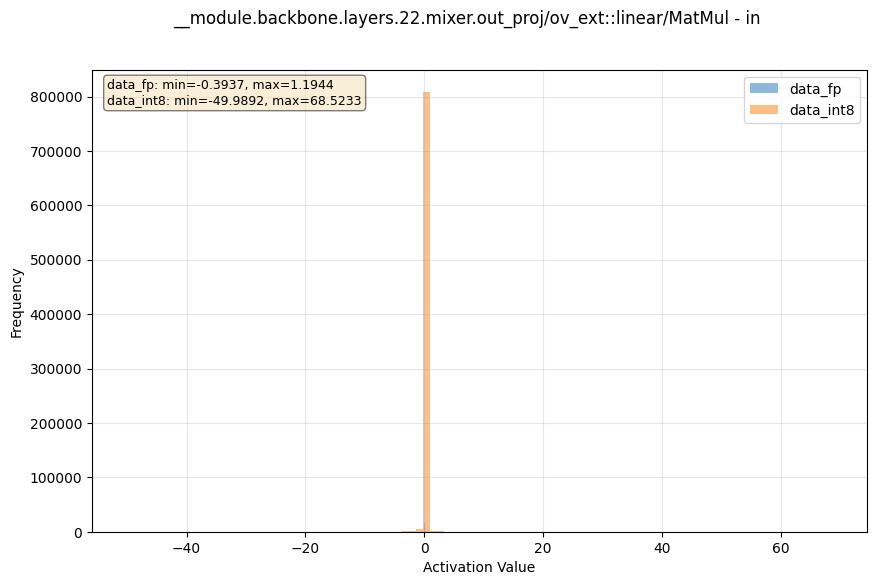

In [34]:
from IPython.display import display

display(all_figs['__module.backbone.layers.22.mixer.out_proj/ov_ext::linear/MatMul']['in'])

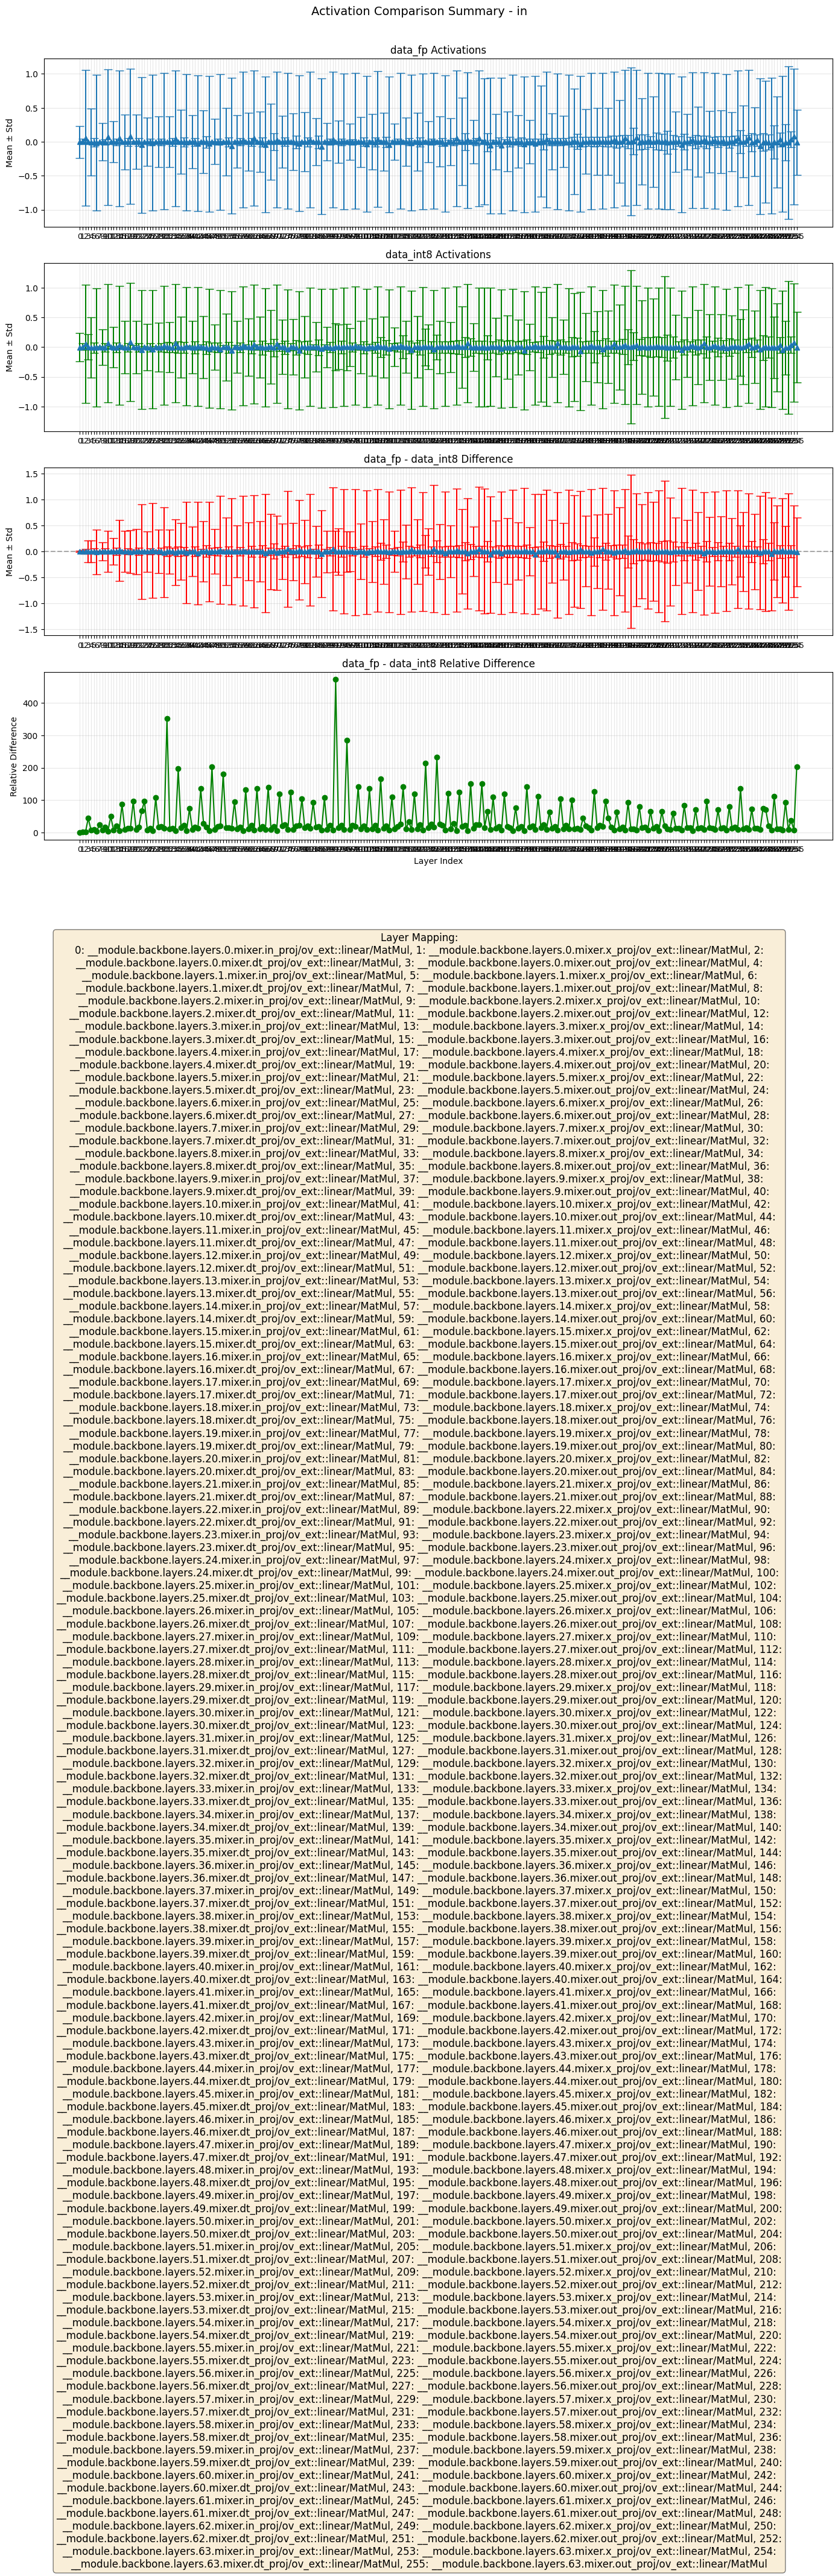

In [16]:
display(summary_figs['in'])